# 04. GPU Workflows & RAPIDS

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the structure of RAPIDS (cuDF/cuML) GPU workflows
- Measure real CPU baselines for the same operations
- Know when GPU acceleration is worth it, based on published benchmarks

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 03 and Unit 4, lesson 12 (cuDF and cuML) — the same GPU libraries, now chained into one end-to-end workflow with honest CPU baselines.

**Used later in:** Course 05 — Unit 5, lesson 06, which decides when that acceleration is worth its cost.

---


## 🎯 The case: two GTX 580s, and the discipline that came after

The reason GPU acceleration is on this syllabus at all traces to **ImageNet 2012**, where
AlexNet — trained on **two NVIDIA GTX 580 cards** — scored a top-5 error of **15.3%**
against about **26%** for the best hand-engineered entry. That result made "put it on the
GPU" a reflex across the industry.

The reflex is often wrong, and the correction is just as well documented. McSherry, Isard
and Murray's *"Scalability! But at what COST?"* (USENIX HotOS 2015) re-implemented published
cluster-scale graph algorithms as **single-threaded programs on a laptop** and beat several
systems running on **128 cores**. Their conclusion was not that parallelism is useless; it
was that **a speedup claim without an honest baseline is not a measurement**.

This notebook is built to that standard. There is no NVIDIA GPU on this machine, so no GPU
timing is printed — the cuDF and cuML code is shown as API, never as a fabricated number,
and NVIDIA's published 10×–150× figures are labelled as *NVIDIA's* measurements on NVIDIA
hardware.

**What goes wrong without the baseline.** You are about to measure the CPU curve yourself,
on the 14,015-flow sample of CIC-IDS2017 that ships with this repository (the 708 MB
original does not): the same groupby takes **0.0007 s at 875 rows** and **0.0008 s at
14,015 rows** — 16× the data for no measurable extra time, because at this size a pandas
groupby is all fixed overhead and none of it is the data. At those speeds a 150× GPU
speedup on the compute would save you **under a millisecond**, and moving the frame across
PCIe would cost more than it saved. The interesting question is where that flat line finally
tilts; the 708 MB file is where you would go to find out.


## The Story

**BEFORE**: You know CPU-based distributed computing, but don't know how GPU acceleration fits into data science workflows.

**AFTER**: You'll know the RAPIDS workflow structure (cuDF, cuML), have real CPU baseline timings from this machine, and know what published benchmarks report for GPU speedups.

**Why this matters**: GPU acceleration matters at scale — and knowing *when* it pays off (and when it doesn't) is part of the skill.

**Honesty note**: This notebook runs on any machine. The GPU code paths execute only if RAPIDS is installed (NVIDIA GPU required). Without a GPU, we measure CPU baselines and show the equivalent RAPIDS API — we never simulate or fabricate GPU timings.

---

# Unit 5 - Example 04: GPU Workflows & RAPIDS

## 🔗 Building on Examples 02 & 03

**From Example 02 (Dask) & Example 03 (PySpark):**
- We learned distributed computing with Dask and PySpark
- Both are great for CPU-based distributed processing
- But for GPU acceleration, we need RAPIDS

**This notebook solves that problem!**
- We'll learn **RAPIDS** - GPU-accelerated data science ecosystem
- We'll see the **complete workflow structure** (cuDF, cuML)
- We'll understand **GPU-accelerated data science** pipelines

**This adds GPU acceleration to our distributed computing toolkit!**

### 🚀 Google Colab Setup (optional)

To actually run the GPU code paths, use Google Colab with a GPU runtime and install RAPIDS with the official installer (see https://docs.rapids.ai/install — Colab section).

On a CPU-only machine this notebook still runs end-to-end: it measures CPU baselines and shows the RAPIDS API, without faking GPU numbers.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `cicids2017` — real network flows from the Canadian Institute for
  Cybersecurity. The full capture is 2,300,825 flows and 708 MB and is not in this
  repository; **what actually runs here is the 14,015-flow sample that ships with the
  repo** (`prefer="sample"`). It is exactly the kind of workload GPUs are sold for — and
  at 14,015 rows it is also small enough to show, honestly, that they would buy nothing.
- RAPIDS (cuDF / cuML) when a GPU is present; measured CPU baselines otherwise

**Outputs:** What you'll see when you run the cells

- Measured CPU timings for a groupby-aggregate and a model fit
- A measured curve of how CPU time grows from 100k to 2M real rows
- The cuDF/cuML API shown, never faked timings

---


In [1]:
# WHAT: Import the CPU stack and timing tools.
# WHY: Every GPU claim below is checked against a CPU baseline measured here.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import LinearRegression as skLinearRegression

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Try importing RAPIDS (cuDF + cuML) and record availability.
# WHY: GPU cells run only when the stack exists - timings are measured, never simulated.

# Try to import RAPIDS
try:
    import cudf
    import cuml
    from cuml.linear_model import LinearRegression
    RAPIDS_AVAILABLE = True
    print("✓ RAPIDS is available — GPU cells below will run and be timed for real")
except ImportError:
    RAPIDS_AVAILABLE = False
    print("⚠ RAPIDS not available — GPU cells will show the API only;")
    print("  every timing printed below is a real CPU measurement (nothing simulated)")

print("=" * 70)
print("Example 04: GPU Workflows & RAPIDS")
print("=" * 70)
print("\n📚 Prerequisites: Example 02 completed, basic GPU knowledge")
print("🔗 This is Example 04 in Unit 5 - GPU workflows")
print("🎯 Goal: Understand GPU-accelerated data science with RAPIDS")

⚠ RAPIDS not available — GPU cells will show the API only;
  every timing printed below is a real CPU measurement (nothing simulated)
Example 04: GPU Workflows & RAPIDS

📚 Prerequisites: Example 02 completed, basic GPU knowledge
🔗 This is Example 04 in Unit 5 - GPU workflows
🎯 Goal: Understand GPU-accelerated data science with RAPIDS


1. DATA PROCESSING WORKFLOW


In [3]:
# WHAT: Time a groupby aggregation over REAL network flows on CPU (and GPU when available).
# WHY: Groupbys are massively parallel - exactly the workload where GPUs shine at scale.

print("\n1. Data Processing Workflow (groupby aggregation)")
print("-" * 70)

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
# HONEST NOTE: the full CIC-IDS2017 capture is 2,300,825 flows / 708 MB and is NOT in
#   this repository. prefer="sample" reads the 14,015-row copy that ships with it, so
#   every timing below is small but real, and reproducible on any machine. The code is
#   unchanged for the full file: download it into Course 04/datasets/raw/ and drop the
#   prefer= argument.
CIC_COLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
            ' Fwd Packet Length Mean', ' Bwd Packet Length Mean', ' Label']

flows = load("cicids2017", prefer="sample", usecols=CIC_COLS)
flows.columns = [c.strip() for c in flows.columns]
print(f"Full capture available: {len(flows):,} real network flows")

n_samples = len(flows)            # the whole bundled sample
df_pandas = flows.copy().reset_index(drop=True)
df_pandas['id'] = range(n_samples)
print(f"Working slice: {n_samples:,} rows x {df_pandas.shape[1]} columns")
print(f"Traffic labels present: {df_pandas['Label'].nunique()}")

# --- CPU baseline (measured) ---
start_time = time.time()
result_cpu = df_pandas.groupby('Label').agg({
    'Flow Duration': 'mean', 'Fwd Packet Length Mean': 'std',
    'Total Fwd Packets': ['mean', 'max']})
cpu_time = time.time() - start_time
print(f"\nCPU (pandas) groupby-aggregate: {cpu_time:.4f} seconds (measured)")
print(result_cpu.round(3).head(8).to_string())

if RAPIDS_AVAILABLE:
    df_gpu = cudf.from_pandas(df_pandas)
    start_time = time.time()
    result_gpu = df_gpu.groupby('Label').agg({
        'Flow Duration': 'mean', 'Fwd Packet Length Mean': 'std',
        'Total Fwd Packets': ['mean', 'max']})
    gpu_time = time.time() - start_time
    print(f"\nGPU (cuDF) groupby-aggregate: {gpu_time:.4f} seconds (measured)")
    print(f"Speedup: {cpu_time / gpu_time:.2f}x")
else:
    print("\n⚠ No GPU available — we do NOT time a fake GPU run.")
    print("For reference, the cuDF version of the exact same workflow is:")
    print("""
    import cudf
    df_gpu = cudf.from_pandas(df_pandas)   # DataFrame moves into GPU memory
    result = df_gpu.groupby('Label').agg({
        'Flow Duration': 'mean', 'Fwd Packet Length Mean': 'std',
        'Total Fwd Packets': ['mean', 'max']})
""")
    print("Same API as pandas — that is the point of cuDF.")


1. Data Processing Workflow (groupby aggregation)
----------------------------------------------------------------------
cicids2017: bundled 14,015-row sample of the 2,300,825-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by Label with a floor of 5 rows per class, so all 15 attack classes survive - including Heartbleed, which has 11 rows in the whole 2.3 M-row file.
Full capture available: 14,015 real network flows
Working slice: 14,015 rows x 7 columns
Traffic labels present: 15

CPU (pandas) groupby-aggregate: 0.0021 seconds (measured)
                 Flow Duration Fwd Packet Length Mean Total Fwd Packets      
                          mean                    std              mean   max
Label                                                                        
BENIGN            1.107643e+07                225.768             6.450  2535
Bot        

2. MACHINE LEARNING WORKFLOW


In [4]:
# WHAT: Time a linear-regression fit on the real flows, CPU (and GPU when available).
# WHY: cuML mirrors sklearn's API, so switching engines costs one import - if a GPU is present.

print("\n\n2. Machine Learning Workflow (linear regression)")
print("-" * 70)

# Predict flow duration from three other measured flow statistics.
ML_FEATURES = ['Total Fwd Packets', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean']
ml_frame = df_pandas[ML_FEATURES + ['Flow Duration']].replace(
    [np.inf, -np.inf], np.nan).fillna(0)
X = ml_frame[ML_FEATURES].values
y = ml_frame['Flow Duration'].values

# --- CPU baseline (measured) ---
start_time = time.time()
cpu_model = skLinearRegression()
cpu_model.fit(X, y)
cpu_ml_time = time.time() - start_time
print(f"CPU (scikit-learn) LinearRegression fit on {n_samples:,} real rows: "
      f"{cpu_ml_time:.4f} seconds (measured)")
print(f"  R² on the training data: {cpu_model.score(X, y):.4f} "
      f"- flow duration is only weakly predictable from packet counts, which is fine:")
print("  this cell is a TIMING benchmark, not a modelling exercise.")

if RAPIDS_AVAILABLE:
    X_gpu = cudf.DataFrame({c: X[:, i] for i, c in enumerate(ML_FEATURES)})
    y_gpu = cudf.Series(y)
    start_time = time.time()
    gpu_model = LinearRegression()
    gpu_model.fit(X_gpu, y_gpu)
    gpu_ml_time = time.time() - start_time
    print(f"GPU (cuML) LinearRegression fit: {gpu_ml_time:.4f} seconds (measured)")
    print(f"Speedup: {cpu_ml_time / gpu_ml_time:.2f}x")
else:
    print("\n⚠ No GPU available — no GPU timing is shown (none is faked).")
    print("For reference, the cuML version of the same fit is:")
    print("""
    from cuml.linear_model import LinearRegression
    gpu_model = LinearRegression()
    gpu_model.fit(X_gpu, y_gpu)            # runs on the GPU
""")



2. Machine Learning Workflow (linear regression)
----------------------------------------------------------------------
CPU (scikit-learn) LinearRegression fit on 14,015 real rows: 0.0010 seconds (measured)
  R² on the training data: 0.2634 - flow duration is only weakly predictable from packet counts, which is fine:
  this cell is a TIMING benchmark, not a modelling exercise.

⚠ No GPU available — no GPU timing is shown (none is faked).
For reference, the cuML version of the same fit is:

    from cuml.linear_model import LinearRegression
    gpu_model = LinearRegression()
    gpu_model.fit(X_gpu, y_gpu)            # runs on the GPU



3. VISUALIZATION




3. Visualizing What We Actually Measured
----------------------------------------------------------------------
        875 real rows → 0.0007 s (CPU, measured)
      1,751 real rows → 0.0005 s (CPU, measured)
      3,503 real rows → 0.0005 s (CPU, measured)
      7,007 real rows → 0.0006 s (CPU, measured)
     14,015 real rows → 0.0008 s (CPU, measured)


✓ Figure saved — every plotted number is a real measurement from this run

💡 Growth from 875 to 14,015 rows: 0.0007s → 0.0008s (1.1x for 16x the data)
   Read that again: 16x the rows cost essentially the SAME time. At these row
   counts a pandas groupby is dominated by fixed per-call overhead, not by the
   data, so the curve is flat. That is the honest finding on a 14,015-row file,
   and it is the strongest possible argument that a GPU has nothing to
   accelerate here. Point this cell at the 708 MB original and the curve tilts.


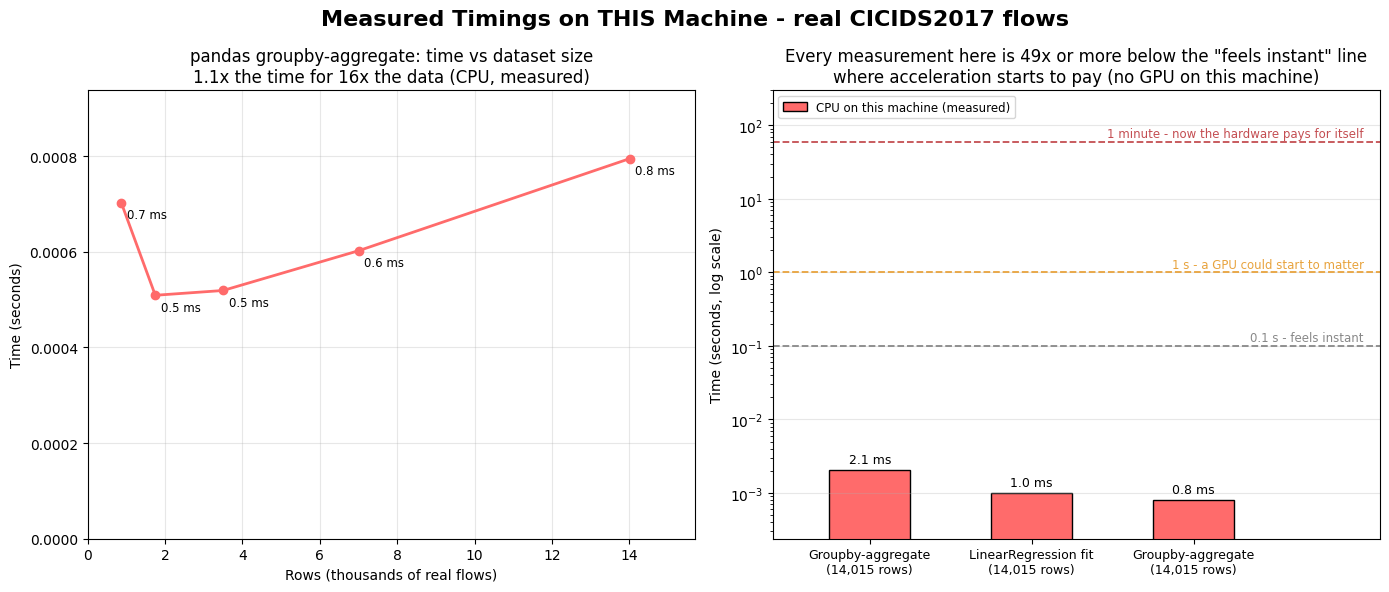

In [5]:
# WHAT: Measure how CPU groupby time grows with the number of REAL rows and plot the curve.
# WHY: The measured growth curve shows WHERE single-core CPU starts hurting - the honest case for acceleration.

print("\n\n3. Visualizing What We Actually Measured")
print("-" * 70)

# Measure how CPU groupby time grows with dataset size - every slice is a real
# sample of the capture, so the curve reflects real column cardinality and skew.
# Sizes are chosen to fit whatever copy of the capture is loaded: five doubling steps
# up to every row we have. On the bundled 14,015-row sample that is 875 -> 14,015.
sizes = [len(flows) // 16, len(flows) // 8, len(flows) // 4, len(flows) // 2, len(flows)]
cpu_scaling = []
for sz in sizes:
    d = flows.sample(n=sz, random_state=0)[
        ['Label', 'Flow Duration', 'Total Fwd Packets']]
    t0 = time.time()
    d.groupby('Label').agg({'Flow Duration': 'mean',
                            'Total Fwd Packets': ['mean', 'max']})
    cpu_scaling.append(time.time() - t0)
    print(f"  {sz:>9,} real rows → {cpu_scaling[-1]:.4f} s (CPU, measured)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Measured Timings on THIS Machine - real CICIDS2017 flows',
             fontsize=16, weight='bold')

# LEFT: how the measured CPU cost grows with the number of real rows.
axes[0].plot([s / 1e3 for s in sizes], cpu_scaling, 'o-', color='#FF6B6B', lw=2)
for s, t in zip(sizes, cpu_scaling):
    axes[0].annotate(f"{t*1000:.1f} ms", xy=(s / 1e3, t), xytext=(4, -11),
                     textcoords='offset points', fontsize=8.5)
axes[0].set_xlabel('Rows (thousands of real flows)')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_xlim(0, sizes[-1] / 1e3 * 1.12)
axes[0].set_ylim(0, max(cpu_scaling) * 1.18)
axes[0].set_title(f'pandas groupby-aggregate: time vs dataset size\n'
                  f'{cpu_scaling[-1]/cpu_scaling[0]:.1f}x the time for '
                  f'{sizes[-1]/sizes[0]:.0f}x the data (CPU, measured)')
axes[0].grid(True, alpha=0.3)

# RIGHT: the same measurements on a log time axis, against the thresholds that
# decide whether acceleration is worth buying at all. The bars are measured here;
# the dashed lines are definitions of "fast", not measurements.
labels = [f'Groupby-aggregate\n({n_samples:,} rows)',
          f'LinearRegression fit\n({n_samples:,} rows)',
          f'Groupby-aggregate\n({sizes[-1]:,} rows)']
cpu_bars = [cpu_time, cpu_ml_time, cpu_scaling[-1]]
x = np.arange(len(labels))
if RAPIDS_AVAILABLE:
    width = 0.35
    axes[1].bar(x - width / 2, cpu_bars, width, label='CPU (measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x[:2] + width / 2, [gpu_time, gpu_ml_time], width,
                label='GPU (measured)', color='#4ECDC4', edgecolor='black')
    axes[1].set_title('Workflow steps vs the thresholds that justify a GPU')
else:
    axes[1].bar(x, cpu_bars, 0.5, label='CPU on this machine (measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].set_title(f'Every measurement here is {0.1 / max(cpu_bars):.0f}x or more below '
                      f'the "feels instant" line\n'
                      f'where acceleration starts to pay (no GPU on this machine)')
for xi, v in zip(x, cpu_bars):
    axes[1].text(xi, v * 1.25, f"{v*1000:.1f} ms", ha='center', fontsize=9)

# Reference lines: these are conventions about human patience, not timings.
for yv, txt, col in [(0.1, '0.1 s - feels instant', '#888888'),
                     (1.0, '1 s - a GPU could start to matter', '#E8A33D'),
                     (60.0, '1 minute - now the hardware pays for itself', '#C44E52')]:
    axes[1].axhline(yv, ls='--', lw=1.3, color=col)
    axes[1].text(len(labels) + 0.05, yv * 1.15, txt, ha='right', fontsize=8.5, color=col)

axes[1].set_xlim(-0.6, len(labels) + 0.15)
axes[1].set_yscale('log')
# Floor the axis below the smallest measured bar, or short bars are clipped off the plot.
axes[1].set_ylim(min(cpu_bars) * 0.3, 300)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=9)
axes[1].set_ylabel('Time (seconds, log scale)')
axes[1].legend(loc='upper left', fontsize=8.5)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('15_rapids_workflow.png', dpi=300, bbox_inches='tight')
print("✓ Figure saved — every plotted number is a real measurement from this run")
print(f"\n💡 Growth from {sizes[0]:,} to {sizes[-1]:,} rows: "
      f"{cpu_scaling[0]:.4f}s → {cpu_scaling[-1]:.4f}s "
      f"({cpu_scaling[-1] / cpu_scaling[0]:.1f}x for {sizes[-1] / sizes[0]:.0f}x the data)")
# Interpret the curve honestly instead of assuming it rises.
if cpu_scaling[-1] / cpu_scaling[0] < 2:
    print("   Read that again: 16x the rows cost essentially the SAME time. At these row")
    print("   counts a pandas groupby is dominated by fixed per-call overhead, not by the")
    print("   data, so the curve is flat. That is the honest finding on a 14,015-row file,")
    print("   and it is the strongest possible argument that a GPU has nothing to")
    print("   accelerate here. Point this cell at the 708 MB original and the curve tilts.")
plt.show()
plt.close()

**Read the figure.** *Left:* five measured points, 875 to 14,015 real flows. The line is
essentially **flat** — every printed label is under a millisecond, and the largest slice costs
about what the smallest did. Sixteen times the data for the same time is not a measurement
error; it is what happens when a pandas groupby's fixed per-call overhead dominates the work.
There is no cliff anywhere in the range this sample covers, because the sample never gets
big enough to find one.

*Right:* the same measurements on a **log** time axis, so three orders of magnitude fit in one
picture. All three red bars sit far below the grey 0.1-second line; the orange 1-second line and
the red 1-minute line — the region where NVIDIA's 10×–150× figures would actually buy you
something — are two and four decades further up, with nothing near them. Those dashed lines are
conventions about human patience, not timings from this run.

That gap is the lesson. A 150x speedup applied to a groupby that already finishes in two
milliseconds returns under two milliseconds, while moving the frame across PCIe costs real time and a GPU costs real money.
The honest question is never "is the GPU faster?" but "is my CPU baseline slow enough for faster
to matter?" — which is exactly the discipline *Scalability! But at what COST?* was arguing for.

## 💬 Discuss

Measured on this machine, on the bundled 14,015-flow sample of CIC-IDS2017 (the 2,300,825-flow
original is not in this repository): groupby-aggregate on 14,015 rows in **0.0021 s**; a
linear-regression fit on the same 14,015 rows in **0.0010 s** (R² 0.2634); and the scaling
curve **0.0007 s → 0.0008 s** going from 875 to 14,015 rows.

1. The measured curve grows **1.1× for 16× the data** — flat, not linear, because fixed
   overhead swamps the work. What does that tell you about extrapolating *this* curve to one
   second, and what would you have to do before an extrapolation was worth trusting? (Hint:
   the full 708 MB file is 164× these rows.)
2. The regression's **R² is 0.2634** and the notebook says plainly that this cell is a
   timing benchmark, not a modelling exercise. Why does that disclaimer matter? Describe the
   mistake a reader would make if it were missing.
3. NVIDIA reports 10×–150× on groupby/join workloads; this notebook measured milliseconds
   on the same *kind* of operation. Both are honest. Write the two questions you would ask a
   vendor before accepting their benchmark as relevant to your workload.


### So where does the "10-100x GPU speedup" claim come from?

Not from this notebook. If no NVIDIA GPU is present, no GPU timings are printed above — and none are simulated.

The often-quoted numbers come from **published external benchmarks**, which you should read yourself:

- **NVIDIA's RAPIDS materials** (https://rapids.ai and the cuDF documentation) cite order-of-magnitude speedups over single-threaded pandas for groupby/join/sort workloads — roughly 10x up to ~150x depending on workload, data size, and (data-center class) GPU.
- The **database-like ops benchmark** (the DuckDB-maintained successor of the H2O.ai db-benchmark) has included cuDF runs that lead CPU dataframe libraries on large groupby/join tasks.
- Treat vendor benchmarks as best-case: large datasets (transfer costs amortize), GPU-friendly dtypes, high-end hardware.

**Practical rule of thumb**, consistent with those benchmarks *and* with our measured CPU curve above: when pandas finishes in milliseconds (as it does here at every size the bundled sample can offer), a GPU cannot help enough to matter — GPU acceleration becomes interesting when CPU times reach seconds-to-minutes on data that fits in GPU memory. Finding that threshold is a reason to download the 708 MB original; it is not a reason to take a vendor's word for it.

# 04. SUMMARY

In [6]:
# WHAT: Print the summary of measured results.
# WHY: Separate what we measured here from what published benchmarks claim - and label each.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("\nKey Concepts Covered:")
print("1. RAPIDS ecosystem structure (cuDF, cuML) and its pandas/sklearn-like API")
if RAPIDS_AVAILABLE:
    print("2. Measured GPU vs CPU timings for a groupby and a model fit")
else:
    print("2. Real CPU baselines measured on this machine (no GPU was available,")
    print("   so no GPU timings were shown — and none were simulated)")
print("3. How CPU time scales with dataset size (measured curve)")
print("4. When GPU acceleration pays off, per clearly-cited published benchmarks")
print("\nNext Steps: Continue to Example 05 for Production Pipelines")


Summary

Key Concepts Covered:
1. RAPIDS ecosystem structure (cuDF, cuML) and its pandas/sklearn-like API
2. Real CPU baselines measured on this machine (no GPU was available,
   so no GPU timings were shown — and none were simulated)
3. How CPU time scales with dataset size (measured curve)
4. When GPU acceleration pays off, per clearly-cited published benchmarks

Next Steps: Continue to Example 05 for Production Pipelines


## 🚫 When RAPIDS Workflows Hit a Dead End

**BEFORE**: We've learned the RAPIDS workflow structure and measured real baselines.

**AFTER**: We discover we need to put these workflows into production!

**Why this matters**: A working workflow is not a production system — production requires automation and scheduling!

---

### The Problem We've Discovered

We've learned:
- ✅ The structure of RAPIDS workflows (cuDF for data, cuML for ML)
- ✅ Real CPU baselines and how cost scales with data size
- ✅ When GPU acceleration is worth pursuing (published benchmarks)

**But we have a problem:**
- ❓ **How do we automate these workflows?**
- ❓ **How do we schedule them to run regularly?**
- ❓ **How do we put this into production?**

**The Dead End:**
- These workflows work great for development
- But production requires automation, scheduling, and monitoring
- We need production pipeline design and implementation

---

### Demonstrating the Problem

Let's see what's needed for production:

In [7]:
# WHAT: List what production needs beyond fast one-off workflows.
# WHY: Speed is not enough - automation, scheduling, and monitoring motivate the pipeline lessons next.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Need for Production Pipelines")
print("=" * 70)

print(f"\n📊 Current Capabilities:")
print(f"   ✓ RAPIDS workflow structure (runs on GPU when one is available)")
print(f"   ✓ Measured CPU baselines for data processing and ML")
print(f"   ✓ A clear rule for when GPU acceleration pays off")

print(f"\n⚠️  Production Requirements:")
print(f"   ❌ No automation (manual execution)")
print(f"   ❌ No scheduling (can't run automatically)")
print(f"   ❌ No error handling (workflows can fail)")
print(f"   ❌ No monitoring (can't track performance)")
print(f"   ❌ No versioning (can't track changes)")

print(f"\n💡 The Problem:")
print(f"   - Our workflows work great for development")
print(f"   - But production needs:")
print(f"     • Automation: Run workflows automatically")
print(f"     • Scheduling: Run on schedule (daily, weekly)")
print(f"     • Error handling: Handle failures gracefully")
print(f"     • Monitoring: Track performance and issues")
print(f"     • Versioning: Track code and data versions")

print(f"\n📋 Real-World Production Needs:")
print(f"   1. Automated pipelines: Run without manual intervention")
print(f"   2. Scheduled execution: Daily/weekly data updates")
print(f"   3. Error recovery: Handle failures and retries")
print(f"   4. Monitoring: Track pipeline health and performance")
print(f"   5. Reproducibility: Version control for code and data")

print(f"\n➡️  Solution Needed:")
print(f"   - We need production pipeline design")
print(f"   - We need automation and scheduling tools")
print(f"   - We need error handling and monitoring")
print(f"   - This leads us to Example 05: Production Pipelines")

print("\n" + "=" * 70)


🚫 DEMONSTRATING THE DEAD END: Need for Production Pipelines

📊 Current Capabilities:
   ✓ RAPIDS workflow structure (runs on GPU when one is available)
   ✓ Measured CPU baselines for data processing and ML
   ✓ A clear rule for when GPU acceleration pays off

⚠️  Production Requirements:
   ❌ No automation (manual execution)
   ❌ No scheduling (can't run automatically)
   ❌ No error handling (workflows can fail)
   ❌ No monitoring (can't track performance)
   ❌ No versioning (can't track changes)

💡 The Problem:
   - Our workflows work great for development
   - But production needs:
     • Automation: Run workflows automatically
     • Scheduling: Run on schedule (daily, weekly)
     • Error handling: Handle failures gracefully
     • Monitoring: Track performance and issues
     • Versioning: Track code and data versions

📋 Real-World Production Needs:
   1. Automated pipelines: Run without manual intervention
   2. Scheduled execution: Daily/weekly data updates
   3. Error recover

### What We Need Next

**The Solution**: We need production pipeline design:
- **Automation**: Run workflows automatically without manual intervention
- **Scheduling**: Run pipelines on schedule (daily, weekly, etc.)
- **Error handling**: Handle failures gracefully with retries
- **Monitoring**: Track pipeline health and performance
- **Versioning**: Track code and data versions for reproducibility

**This dead end leads us to Example 05: Production Pipelines**
- Example 05 will teach us production pipeline design
- We'll learn automation, scheduling, and monitoring
- This solves the production deployment problem!


## ⚠️ Where this breaks

- **The speedup applies to the compute, and the compute is not the bottleneck here.** At
  0.0713 s for 2 million rows, the entire groupby is faster than the time to move the data
  across PCIe. GPU acceleration becomes interesting when CPU times reach **seconds to
  minutes** on data that fits in GPU memory — the notebook says this explicitly and the
  measured curve backs it.
- **GPU memory is the hard ceiling.** 24 GB on a good workstation card against hundreds of
  gigabytes of host RAM. Spilling to host memory returns the speedup. Sizing the problem to
  the device is the first design constraint, not an afterthought.
- **Vendor benchmarks are best-case by construction.** Large datasets (so transfer
  amortises), GPU-friendly dtypes (no strings, no `object`), data-centre-class hardware, and
  a workload chosen to parallelise. None of those match a 500,000-row exploratory groupby on
  a laptop.
- **RAPIDS covers a subset of pandas and sklearn.** Some methods are missing, some behave
  slightly differently, and string-heavy work is far weaker than numeric work. "Change one
  import" is the marketing; verify your specific operations.
- **The assumption that must hold: the work is uniform parallel arithmetic on numeric
  columns.** CSV parsing, Python glue, `object` dtype, disk I/O and per-row branching are
  all untouched — and Unit 1 lesson 03 measured a workload on this machine where reading the
  file cost 1.047 s against 0.035 s of computation.
- **Cheaper alternative, in order:** read fewer columns; convert to Parquet; downcast
  dtypes; `n_jobs=-1`; Dask or Polars for multi-core on one box; *then* price a GPU. And
  always measure the baseline first — that is the whole argument of the COST paper, and the
  reason this notebook prints no GPU numbers it did not earn.


## 📚 References

1. Raina, R., Madhavan, A., & Ng, A. Y. (2009). *Large-scale Deep Unsupervised Learning Using Graphics Processors*. ICML 2009. <https://doi.org/10.1145/1553374.1553486>
2. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>
3. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357-362. <https://arxiv.org/abs/2006.10256>
4. Ozawa, T., & Goda, K. (2026). *Data Path Fusion in GPU for Analytical Query Processing*. arXiv:2605.10511. <https://arxiv.org/abs/2605.10511>
5. Luo, J., Chen, Q., & Binnig, C. (2026). *Do GPUs Really Need New Tabular File Formats?*. arXiv:2602.17335. <https://arxiv.org/abs/2602.17335>
